### Mathematical Representation of Edge Vertices

Let $\mathcal{E}_{2D}$ denote the set of pixel coordinates $(u, v)$ that constitute the detected edge in the 2D image plane.
Let $D(u, v)$ represent the depth value at a given pixel $(u, v)$.
Let $K$ be the camera intrinsic matrix defined as:

$$
K = \begin{bmatrix} f_x & 0 & c_x \\ 0 & f_y & c_y \\ 0 & 0 & 1 \end{bmatrix}
$$

The set of 3D vertices $\mathcal{V}_{edge}$ (as stored in the PLY file) corresponding to the detected edge is obtained by back-projecting the pixels in $\mathcal{E}_{2D}$ into 3D space:

$$
\mathcal{V}_{edge} = \left\{ \mathbf{P} \in \mathbb{R}^3 \;\middle|\; \mathbf{P} = D(u,v) \cdot K^{-1} \begin{bmatrix} u \\ v \\ 1 \end{bmatrix}, \quad \forall (u, v) \in \mathcal{E}_{2D} \right\}
$$

Explicitly, the coordinates $(X, Y, Z)$ for each vertex are calculated as:

$$
\begin{aligned}
X &= \frac{(u - c_x) \cdot D(u, v)}{f_x} \\
Y &= \frac{(v - c_y) \cdot D(u, v)}{f_y} \\
Z &= D(u, v)
\end{aligned}
$$

### Output Dimension Space of Detected Edge

The detected 2D edge $\mathcal{E}_{2D}$ represents the boundary of the segmented object in the image. It is defined as a set of $N$ points in the 2D image coordinate system.

The output dimension space is:

$$
\mathcal{E}_{2D} \in \mathbb{R}^{N \times 2}
$$

Where:
*   $N$ is the number of points along the contour/edge.
*   $2$ represents the $(u, v)$ pixel coordinates for each point.

Explicitly, the data structure is a matrix:

$$
\mathcal{E}_{2D} = \begin{bmatrix} u_1 & v_1 \\ u_2 & v_2 \\ \vdots & \vdots \\ u_N & v_N \end{bmatrix}
$$

### Output Dimension Space of FoundationStereo Disparity Map

The FoundationStereo model outputs a dense disparity map $\mathcal{D}$ that encodes the depth information for the entire scene. For an input image resolution of height $H$ and width $W$, the output space is:

$$
\mathcal{D} \in \mathbb{R}^{H \times W}
$$

This can be represented as a matrix where each element $d_{u,v}$ corresponds to the scalar disparity value (in pixels) at the image coordinate $(u, v)$:

$$
\mathcal{D} = \begin{bmatrix} 
d_{1,1} & d_{1,2} & \cdots & d_{1,W} \\ 
d_{2,1} & d_{2,2} & \cdots & d_{2,W} \\ 
\vdots & \vdots & \ddots & \vdots \\ 
d_{H,1} & d_{H,2} & \cdots & d_{H,W} 
\end{bmatrix}
$$

### Construction of 4D Cost Volume from 3D Feature Maps

In stereo matching deep learning architectures, a key step is transforming extracted 2D image features into a cost volume that represents the similarity between left and right pixels at various disparity levels.

**1. Input: 3D Feature Maps**
Let $F_L$ and $F_R$ be the feature maps extracted from the left and right images using a shared backbone network (e.g., CNN or Transformer). These are 3D tensors defined in the space:

$$
F_L, F_R \in \mathbb{R}^{C \times H \times W}
$$

Where:
*   $C$: Number of feature channels.
*   $H, W$: Spatial height and width of the feature map.

**2. Transformation: Disparity Shifting and Concatenation**
To construct the cost volume, we compare the left feature map $F_L$ with the right feature map $F_R$ shifted by a disparity candidate $d$. The disparity range is defined as $d \in \{0, 1, \dots, D_{max}-1\}$.

For each disparity $d$, we shift the right feature map and concatenate it with the left feature map along the channel dimension:

$$
V_d(u, v) = \text{Concat}\left( F_L(u, v), F_R(u - d, v) \right)
$$

This operation results in a feature vector of size $2C$ at each pixel $(u, v)$ for each disparity $d$.

**3. Output: 4D Cost Volume Tensor**
Stacking these concatenated features across the disparity dimension results in a 4D Cost Volume Tensor $\mathcal{V}$:

$$
\mathcal{V} \in \mathbb{R}^{2C \times D_{max} \times H \times W}
$$

Where:
*   $2C$: The combined feature dimension (channels).
*   $D_{max}$: The maximum disparity range (depth dimension).
*   $H, W$: Spatial dimensions.

This 4D tensor is then typically processed by 3D convolutions to aggregate context and regress the final disparity map.

### Morphological Smoothing of Object Boundaries

Depth edges extracted from disparity maps or segmentation masks often exhibit noise, jaggedness, or small discontinuities. Morphological operations, specifically **Erosion** and **Dilation**, are standard image processing techniques used to smooth these boundaries and improve the geometric quality of the detected object.

**1. Dilation ($\oplus$)**
Dilation adds pixels to the boundaries of objects in an image. It uses a structuring element $B$ (e.g., a small square or disk) to probe the input image $A$.
Mathematically, the dilation of $A$ by $B$ is defined as:

$$
A \oplus B = \{ z \mid (\hat{B})_z \cap A \neq \emptyset \}
$$

*   **Effect:** It expands the object boundary, filling in small holes and connecting disjointed edge segments.

**2. Erosion ($\ominus$)**
Erosion removes pixels on object boundaries.
Mathematically, the erosion of $A$ by $B$ is defined as:

$$
A \ominus B = \{ z \mid (B)_z \subseteq A \}
$$

*   **Effect:** It shrinks the object boundary, removing small extrusions and isolated noise pixels.

**3. Morphological Closing (Smoothing)**
To smooth the object boundary effectively, these operations are often combined. A common sequence is **Closing**, which is a dilation followed by an erosion:

$$
A \bullet B = (A \oplus B) \ominus B
$$

*   **Application:** Closing fills small gaps in the depth edge and smooths the contour without significantly changing the overall size or shape of the object. This results in a continuous and cleaner boundary for 3D projection.

### Theory of the Canny Edge Detector

The Canny edge detector, proposed by John Canny in 1986, is a multi-stage algorithm designed to optimally detect edges in images by satisfying three criteria: good detection (minimizing false positives and negatives), good localization (edges close to true edges), and single response (one detection per edge). The algorithm proceeds through the following stages:

**1. Gaussian Smoothing**
The input image $I(x, y)$ is convolved with a Gaussian kernel $G_\sigma(x, y)$ to reduce noise and smooth the image:

$$
I_{\text{smooth}}(x, y) = I(x, y) \ast G_\sigma(x, y)
$$

where $G_\sigma(x, y) = \frac{1}{2\pi\sigma^2} e^{-\frac{x^2 + y^2}{2\sigma^2}}$ and $\sigma$ controls the degree of smoothing.

**2. Gradient Computation**
The gradient magnitude $M(x, y)$ and direction $\theta(x, y)$ are computed using Sobel operators or other derivative filters:

$$
\begin{aligned}
G_x &= \frac{\partial I_{\text{smooth}}}{\partial x}, \quad G_y = \frac{\partial I_{\text{smooth}}}{\partial y} \\
M(x, y) &= \sqrt{G_x^2 + G_y^2} \\
\theta(x, y) &= \arctan\left(\frac{G_y}{G_x}\right)
\end{aligned}
$$

**3. Non-Maximum Suppression (NMS)**
To achieve thin edges, non-maximum suppression is applied. For each pixel, the gradient magnitude is compared with its neighbors along the gradient direction. A pixel is retained as an edge candidate only if its magnitude is locally maximal:

$$
M_{\text{NMS}}(x, y) = 
\begin{cases} 
M(x, y) & \text{if } M(x, y) \geq M(x + \Delta x, y + \Delta y) \text{ along } \theta(x, y) \\
0 & \text{otherwise}
\end{cases}
$$

**4. Double Thresholding and Hysteresis**
Two thresholds, $T_{\text{low}}$ and $T_{\text{high}}$ (where $T_{\text{low}} < T_{\text{high}}$), classify edge pixels:

- **Strong edges**: $M_{\text{NMS}}(x, y) \geq T_{\text{high}}$
- **Weak edges**: $T_{\text{low}} \leq M_{\text{NMS}}(x, y) < T_{\text{high}}$
- **Non-edges**: $M_{\text{NMS}}(x, y) < T_{\text{low}}$

Hysteresis tracking connects weak edges to strong edges: a weak edge pixel is retained if it is connected (8-connectivity) to a strong edge pixel, forming continuous contours.

**5. Output**
The final binary edge map $\mathcal{E}$ contains pixels classified as edges:

$$
\mathcal{E}(x, y) = 
\begin{cases} 
1 & \text{if } (x, y) \text{ is a strong or connected weak edge} \\
0 & \text{otherwise}
\end{cases}
$$

This multi-stage approach ensures robust edge detection with minimal noise sensitivity and accurate localization.

# Step 7: Iterative Contour Detection Algorithm

**Objective:** Find a closed loop boundary from filtered depth edges using an iterative morphological closing approach.

**Algorithm:**

**Initialize:**
- $M_0$ = binary edge mask from filtered depth edges
- $H, W$ = ROI dimensions (height, width)
- $T_{min} = \frac{1}{2}\min(H, W)$ = minimum dimension threshold
- $N_{max} = 5$ = maximum iterations
- $n = 0$ = iteration counter
- $C^* = \emptyset$ = best loop (initially empty)
- $M_n = M_0$ = working mask

**Iterate while** $C^* = \emptyset$ **and** $n \leq N_{max}$:

1. **Find contours:** $\{C_i\} = \text{FindContours}(M_n)$

2. **Filter by size:** For each contour $C_i$:
   - Compute bounding box: $\text{bbox}(C_i) = (x, y, w, h)$
   - If $\max(w, h) \geq T_{min}$: add $C_i$ to candidate set $\mathcal{L}$

3. **Select best loop:** If $\mathcal{L} \neq \emptyset$:
   - $C_{best} = \underset{C_i \in \mathcal{L}}{\arg\max} \, \text{Area}(C_i)$
   - Apply polygon approximation: $C_{approx} = \text{approxPolyDP}(C_{best}, \epsilon \cdot \text{Perimeter}(C_{best}))$
   - If $|C_{approx}| \geq 4$ vertices: $C^* = C_{approx}$ and **break**

4. **Gap filling:** Else (if $\mathcal{L} = \emptyset$):
   - If $n < N_{max}$:
     - $M_{n+1} = M_n \bullet B$ (morphological closing with kernel $B$)
     - $n \leftarrow n + 1$
   - Else: **break** (max iterations reached)

**Output:** $C^*$ (best closed loop or $\emptyset$ if none found)

---

**Key Parameters:**
- $T_{min}$: Size threshold (≥50% of ROI span ensures significant coverage)
- $\epsilon = 0.005$: Polygon approximation tolerance (controls smoothness vs. detail)
- $B$: Elliptical structuring element for morphological closing
- $N_{max}$: Safety limit to prevent infinite loops

**Design Rationale:**
- **Lazy morphology:** Only applies closing when needed, avoiding unwanted edge merging
- **Size-based filtering:** Ensures detected boundary is object boundary, not a small artifact
- **Early termination:** Stops immediately when a valid contour is found, minimizing processing

Found 50 images. Showing first 4.


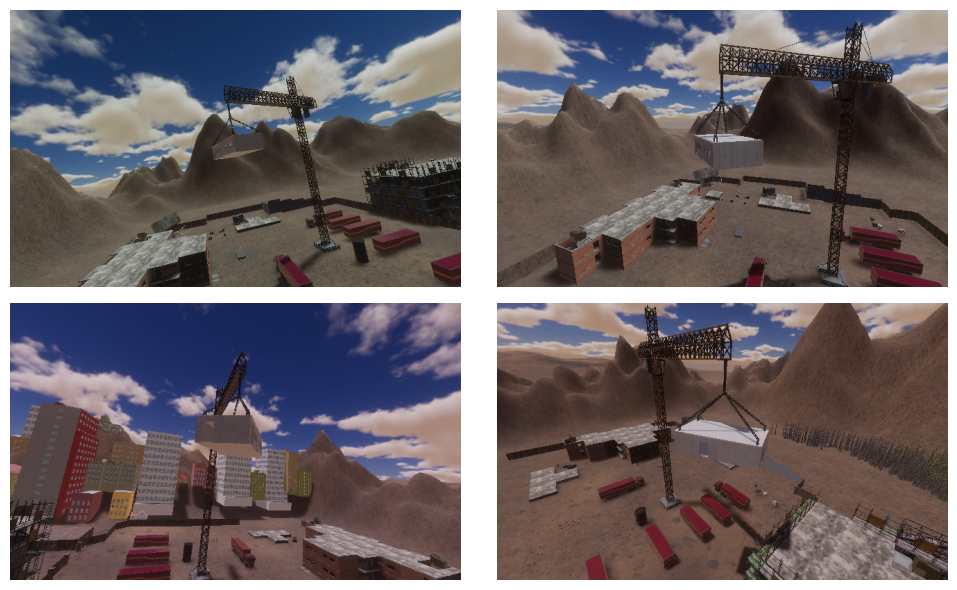

In [7]:
import matplotlib.pyplot as plt
import glob
import os
import cv2
import math

# Path to batch inputs relative to this notebook
input_dir = '../run_files/batch_inputs'

# Find all camera1 images (Unity RGB inputs)
# Search recursively in subfolders
image_paths = glob.glob(os.path.join(input_dir, '**', '*camera1.png'), recursive=True)

# Sort to ensure consistent order
image_paths.sort()

# Limit to 4 images
num_images = min(len(image_paths), 4)

if num_images == 0:
    print(f"No images found in {input_dir}")
else:
    print(f"Found {len(image_paths)} images. Showing first {num_images}.")

    # Create figure (2 rows, 2 columns)
    fig, axes = plt.subplots(2, 2, figsize=(10, 6))
    axes = axes.flatten()

    for i in range(4):
        ax = axes[i]
        if i < num_images:
            img_path = image_paths[i]
            # Read image (OpenCV reads as BGR, convert to RGB)
            img = cv2.imread(img_path)
            if img is not None:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                ax.imshow(img)
                # Title removed as requested
            else:
                ax.text(0.5, 0.5, "Error loading", ha='center')
        
        ax.axis('off')

    plt.tight_layout()
    plt.show()

### Structure of Unity Camera JSON (`frame_data.json`)

The following JSON structure outlines the specific keys and fields accessed by the analysis scripts in this workspace, based on `step0.frame_data.json`.

```json
{
  "captures": [
    {
      "@type": "type.unity.com/unity.solo.RGBCamera",  // Used to identify RGB cameras
      "id": "camera1",                                  // Camera ID (e.g., "camera1")
      "filename": "step0.camera1.png",                  // Used to match specific image files
      "dimension": [650.0, 400.0],                      // [Width, Height]
      "matrix": [                                       // 3x3 Projection Matrix (Row-major)
        0.781, 0.0, 0.0,
        0.0, 1.269, 0.0,
        0.0, 0.0, -1.000
      ],
      "position": [46.76, 36.49, 111.58],               // Camera World Position [x, y, z]
      "rotation": [0.019, 0.847, -0.064, 0.525]         // Camera World Rotation Quaternion [x, y, z, w]
    },
    {
      "@type": "type.unity.com/unity.solo.RGBCamera",
      "id": "camera2",                                  // Second Camera ID
      "filename": "step0.camera2.png",
      "dimension": [650.0, 400.0],
      "matrix": [
        0.781, 0.0, 0.0,
        0.0, 1.269, 0.0,
        0.0, 0.0, -1.000
      ],
      "position": [46.67, 36.49, 111.41],               // Camera 2 Position (Baseline offset)
      "rotation": [0.019, 0.847, -0.064, 0.525]
    }
  ],
  "metrics": [
    // ... (indices 0 and 1: scenario_iteration, random-seed ignored)
    {
      "id": "metadata",                                 // Metadata metric containing object transforms
      "values": [
        {
          "instances": [
            {
              "instanceId": "1",                        // Corner/Object ID
              "transformRecord": {
                "position": [81.56, 32.66, 99.69]       // Object/Corner World Position [x, y, z]
              }
            }
            // ... (other instances/corners)
          ]
        }
      ]
    }
  ]
}
```